In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
data = pd.read_csv("/content/housing.csv")

print("Dimensiones del dataset:", data.shape)

data.head()

Dimensiones del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data = data.dropna()

In [5]:
data = pd.get_dummies(data)

In [6]:
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

print("Número de características:", X.shape[1])

Número de características: 13


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
modelo_lineal = LinearRegression()

modelo_lineal.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)

In [9]:
mse_lineal = mean_squared_error(y_test, pred_lineal)

print("Error modelo lineal:", mse_lineal)

Error modelo lineal: 4802173538.604137


In [10]:
print("Primeras 100 predicciones:")

print(pred_lineal[:100])

Primeras 100 predicciones:
[201882.95986765 147279.68214384 207796.60979847 180487.57672192
 190323.92313024  95437.89710399 287156.45161243 257624.77180537
 385383.55615124  62548.19755137   4806.24629041 108258.33857357
 255513.15993961 202556.2684436   65630.46713647 181214.85214025
 218431.18522061 286810.22166068 208135.51260371 271989.3851134
 238248.82578016 162417.4663986  223215.95421238  74212.80779819
 221010.78857776 265144.44362834 265868.58174704 244099.75243044
 251319.93609619  91225.47916733 146121.49207085 203822.06117391
 205639.89735187 214676.86137829 280335.08173505 450192.8971774
 532860.2600645   78632.96868749 172097.9140054  334605.75227055
 194109.94304495  54106.54557839 248464.91414126 202495.50433655
 193613.17560434 152884.88505296 160963.43142268 361150.21481679
 210810.41106022 221185.48360462 213446.76957599 222221.31011048
 145059.07468416 221162.20140655 195811.24668036 294698.82314694
 221653.89932346 242315.8564611  423102.88638503  40717.54776968


In [11]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

modelo_poly = LinearRegression()

modelo_poly.fit(X_poly_train, y_train)

pred_poly = modelo_poly.predict(X_poly_test)

In [12]:
mse_poly = mean_squared_error(y_test, pred_poly)

print("Error modelo polinómico:", mse_poly)

Error modelo polinómico: 21240957484.83959


In [14]:
# convertir a numpy
X_train_np = np.array(X_train, dtype=float)
y_train_np = np.array(y_train, dtype=float)

# ecuacion normal
theta = np.linalg.inv(X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

# predicciones
pred_normal = np.array(X_test, dtype=float) @ theta

In [15]:
mse_poly = mean_squared_error(y_test, pred_poly)

print("Error modelo polinómico:", mse_poly)

Error modelo polinómico: 21240957484.83959


In [18]:
import pandas as pd
import numpy as np

data = pd.read_csv("/content/housing.csv")

In [20]:
data = data.dropna()

In [21]:
data = pd.get_dummies(data)

In [22]:
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

In [23]:
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [24]:
X = X.dropna()
y = y.loc[X.index]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [26]:
X_train_np = X_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

In [27]:
theta = np.linalg.pinv(X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

In [28]:
pred_normal = X_test_np @ theta

In [29]:
print(pred_normal[:100])

[201882.95986758 147279.68214017 207796.60979823 180487.57672121
 190323.9231224   95437.8971011  287156.45160811 257624.77180653
 385383.55614855  62548.19755638   4806.24629936 108258.33857279
 255513.15994113 202556.26844373  65630.46713788 181214.85214194
 218431.1852188  286810.22166016 208135.5125942  271989.38511021
 238248.82578091 162417.46639974 223215.95421263  74212.80779647
 221010.78857017 265144.44362561 265868.58174632 244099.75242926
 251319.93609247  91225.47916556 146121.49207056 203822.06117413
 205639.89735248 214676.86137583 280335.08173587 450192.89717127
 532860.26006392  78632.96868902 172097.91400618 334605.75226912
 194109.94304154  54106.54557543 248464.91414241 202495.50433545
 193613.17560001 152884.88505345 160963.4314201  361150.21481499
 210810.41105691 221185.48360556 213446.76957238 222221.3101072
 145059.07468329 221162.20140769 195811.24667667 294698.82314611
 221653.89932512 242315.85645282 423102.88638329  40717.54776861
 159041.37436311 166775.35

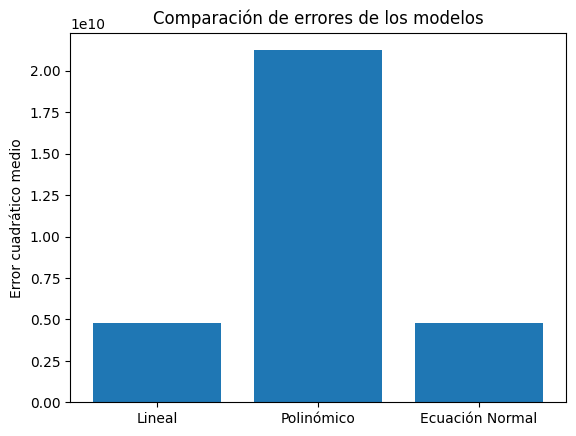

In [31]:
mse_normal = mean_squared_error(y_test, pred_normal)

modelos = ["Lineal", "Polinómico", "Ecuación Normal"]

errores = [mse_lineal, mse_poly, mse_normal]

plt.figure()

plt.bar(modelos, errores)

plt.title("Comparación de errores de los modelos")

plt.ylabel("Error cuadrático medio")

plt.show()